<img src = "https://www.journalism.co.uk/assets/135/IiB_screenshot.jpg_resized_460_.jpeg" align = right width = 450>
<h1 align = left> Data 765: Python Fundamentals for Data Science</h1>
<h2 align = left> Lecture 12 | Exploratory Data Analysis (I) </h2>
<h3 align = left> Yinxian Zhang | QC Sociology</h3>

# Table of Contents

<div class = "alert alert-info">

1. [What is Exploratory Data Analysis](#1)<br>
2. [EDA with <code>pandas</code> and <code>matplotlib</code>](#2)<br>
    2.1 [Univariate Analysis](#2.1)<br>
    2.2 [Bivariate Analysis](#2.2)<br>
3. [More Resources](#3)<br>
    
</div>
<hr>

In the last session, we walked through **the dynamic, trial-and-error, back-and-forth process** of processing real-life datasets. Today, we are going to repeat the same process, this time with a focus on **exploratory data analysis**. You will see the power of visualization in facilitating data analysis. 

As always, let's import libraries first. 

In [1]:
import pandas as pd                
import numpy as np   

### The `matplotlib` library for visualization in Python

`matplotlib` is a visualization library that **works with `numpy` arrays** and **`pandas` DataFrames or Series**. 

It has been one of the most popular and long-lived Python packages (born in 2002, earlier than `pandas`). There are other visualization tools, such as `seaborn`, whose APIs may be more modern and streamlined. But these tools are all built on `matplotlib` and their functionalities are not as powerful. 

In this session, we are going to interact with `matplotlib` through the `pandas` platform, especially the `df.plot()` method. We are going to get a taste of `seaborn` when we learn about advanced plot types. 

In [2]:
import matplotlib.pyplot as plt                     # import visualization library!

In addition to importing the visualization library, in a Jupyter notebook environment, we also want to display the plot we produce in a cell (just like any other outputs). To this end, we need one more line:

In [3]:
%matplotlib inline                                  

---

# What is Exploratory Data Analysis (EDA)? <a id=1></a>

[Wikipedia](https://en.wikipedia.org/wiki/Exploratory_data_analysis) defines exploratory data analysis as:

>[A]n approach of analyzing data sets to summarize their main characteristics, often using **statistical graphics** and other **data visualization** methods. A statistical model can be used or not, but **primarily EDA is for seeing what the data can tell us beyond the formal modeling or hypothesis testing** task. 

In other words, **EDA** explores data primarily with **visualization** and does not require any modeling or hypothesis testing. We just let the data itself tell us the story. 

However, there are so many topics under data visualization that we can barely cover anything in depth within just one or two sessions. So today we will only focus on a few basic visualization tools, and I'd encourage you to take a course about visualization if interested. 

# EDA with `pandas` and `matplotlib` <a id=2></a>

We are going to repeat what we did with the 2012 GSS dataset last week, and we will add in the component of EDA. So let's read in the data first:

In [5]:
path = 'https://raw.githubusercontent.com/UC-MACSS/persp-analysis/master/assignments/exploratory-data-analysis/data/gss2012.csv'

df = pd.read_csv(path, header=0)       # path is either the path to a local file or http address to an online data file          

## Initial inspection

Let's begin with an initial inspection of the dataset. At this point, you should be very familiar with the couple of commands that help you get a sense of the data.

In [6]:
# returns the first 5 rows by default
df.tail()    

,year,id,wrkstat,wrkslf,wrkgvt,marital,sibs,childs,age,educ,...,south,divlaw2,age.f,mslm_spk.high,mslm_spk.yes,grass.legal,age2,relig2,dem,science_quiz.f
1969,2012,1970.0,WORKING FULL TIME,SOMEONE ELSE,GOVERNMENT,Never married,3.0,0.0,61.0,4 years,...,Nonsouth,Same/easier,61.0,NaN,NaN,0.0,>=31,NaN,1.0,NaN
1970,2012,1971.0,"UNEMPLOYED, LAID OFF",SOMEONE ELSE,GOVERNMENT,Never married,9.0,0.0,53.0,1 yr coll,...,Nonsouth,NaN,53.0,0.0,0.0,100.0,>=31,Catholic,1.0,7.0
1971,2012,1972.0,WORKING FULL TIME,SOMEONE ELSE,PRIVATE,Married,2.0,2.0,48.0,1 yr coll,...,Nonsouth,Same/easier,48.0,0.0,0.0,NaN,>=31,Catholic,0.0,NaN
1972,2012,1973.0,WORKING FULL TIME,SOMEONE ELSE,GOVERNMENT,Never married,3.0,8.0,37.0,12th grade,...,Nonsouth,More difficult,37.0,NaN,NaN,0.0,>=31,Catholic,0.0,5.0
1973,2012,1974.0,KEEPING HOUSE,NaN,NaN,Never married,3.0,0.0,22.0,12th grade,...,Nonsouth,NaN,22.0,0.0,0.0,100.0,<=30,Protestant,0.0,NaN


In [7]:
# returns (# of rows/obs, # of columns/variables)
df.shape

(1974, 221)

In [8]:
# all-in-one command, returns full information of the dataframe

df.info(verbose=True, null_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 221 columns):
 #    Column            Non-Null Count  Dtype  
---   ------            --------------  -----  
 0    year              1974 non-null   int64  
 1    id                1974 non-null   float64
 2    wrkstat           1919 non-null   object 
 3    wrkslf            1894 non-null   object 
 4    wrkgvt            1857 non-null   object 
 5    marital           1974 non-null   object 
 6    sibs              1971 non-null   float64
 7    childs            1971 non-null   float64
 8    age               1969 non-null   float64
 9    educ              1972 non-null   object 
 10   degree            1974 non-null   object 
 11   sex               1974 non-null   object 
 12   race              1974 non-null   object 
 13   polviews          1874 non-null   object 
 14   partyid           1906 non-null   object 
 15   mobile16          1965 non-null   object 
 16   born              1971

C:\Users\YINXIAN ZHANG\AppData\Local\Temp\ipykernel_8576\2980356624.py:3: FutureWarning: null_counts is deprecated. Use show_counts instead
  df.info(verbose=True, null_counts=True)


Then let's limit the dataset to the few main variables that we are interested in. 

<p style='color:orange'> Again, caution: save your cropped dataframe to another variable. **Do Not Overwrite** the orginal dataframe in case you need to use other variables later! </p>

In [12]:
data =  df[['pres08',                                     
            'polviews',                                  
            'id', 'age', 'sex', 'race', 'educ',                   
            'tvhours'                              # I added a numerical variable this time  
        ]]

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1974 entries, 0 to 1973
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pres08    1222 non-null   object 
 1   polviews  1874 non-null   object 
 2   id        1974 non-null   float64
 3   age       1969 non-null   float64
 4   sex       1974 non-null   object 
 5   race      1974 non-null   object 
 6   educ      1972 non-null   object 
 7   tvhours   1298 non-null   float64
dtypes: float64(3), object(5)
memory usage: 123.5+ KB


## Get familiar with your data...then perform data transformation as needed

Again, after reading in data, your primary task is to explore the dataset with the below questions in mind: 

- are there any **missing values**? Would the missing values influence my analysis?
- are there any **illegal inputs** / special values that may affect my analysis? 
- are the variables in the desired **`dtype`s and formats**? 
- for **numerical variables**: what are the **measuring units**? are they discrete or continuous? 
- for **categorial variables**: how are they **coded**? are they **nominal or ordinal**?
- do I need to **recode** some of the variables?
- what are the **distributions** of the variables? Any **outliers or pecularities** that warrant further investigation?
- ...

We already explored each of the variables last time, and we found a few issues:

1. clumsy variable names;
2. wrong `dtype` for `id`;
3. **unordered categories under `polviews`;
4. **too many (unordered) categories under `educ`; and
5. a lot of missing values of `pres08`.

So let's jump right into data transformation.

In [14]:
# change variable names:

data = data.rename(columns={'pres08':'pres', 'polviews':'pol'})         # not really necessary, for class demo only

data.columns

Index(['pres', 'pol', 'id', 'age', 'sex', 'race', 'educ', 'tvhours'], dtype='object')

In [15]:
# change dtypes:

data['id'] = data.id.astype('object')             # str rather than float

## Recode variables 
### Ordered categorical variables

In [16]:
# show unique categories of "pol":

data.pol.unique()

array(['Moderate', 'SlghtCons', 'Liberal', 'Conserv', 'ExtrmLib', nan,
       'ExtrmCons', 'SlghtLib'], dtype=object)

`pol`, our main variable of interest, is a categorical variable that features 7 categories ranging from "extremely liberal" to "extremely conservative". But the variable itself is not explicitly marked as an "ordinal variable", nor is it presenting the natural order of the variable. 

**`pandas` allows you to specify the type (nominal v.s. ordinal) and order of a categorical variable** for more fine-grain analysis: `pd.Categorical()` is the function that deals with categorical variables in pandas. You may want to check out the full syntax. 

In [17]:
# transform and save it to a new variable

data['pol_ordered'] = pd.Categorical(data.pol, 
            # manually put in the right order
            categories=['ExtrmLib', 'Liberal', 'SlghtLib', 'Moderate', 'SlghtCons', 'Conserv', 'ExtrmCons'],   # ordered!
            # specify that it is an ordered (ordinal) variable
            ordered=True)                  

Upon transforming the variable, you may choose to overwrite the original variable or save it to a new variable, depending on your need. But you should always SAVE it for future use.

In [18]:
data.pol_ordered.unique()     #  double check 

['Moderate', 'SlghtCons', 'Liberal', 'Conserv', 'ExtrmLib', NaN, 'ExtrmCons', 'SlghtLib']
Categories (7, object): ['ExtrmLib' < 'Liberal' < 'SlghtLib' < 'Moderate' < 'SlghtCons' < 'Conserv' < 'ExtrmCons']

Behind the scene, **`pandas` assigns a numeric code to each category for ordering purposes.** So `ExtrmLib` is 0, the "lowest" category, and `ExtrmCons` is 6, the "highest" category. 

One thing to note: missing values `NaN` will be coded as `-1` in an ordinal variable!!

In [19]:
data.pol_ordered                  # descriptive labels (what you see)

0        Moderate
1       SlghtCons
2       SlghtCons
3       SlghtCons
4         Liberal
          ...    
1969      Liberal
1970     Moderate
1971     Moderate
1972    SlghtCons
1973     Moderate
Name: pol_ordered, Length: 1974, dtype: category
Categories (7, object): ['ExtrmLib' < 'Liberal' < 'SlghtLib' < 'Moderate' < 'SlghtCons' < 'Conserv' < 'ExtrmCons']

In [20]:
data.pol_ordered.cat.codes       # numeric codes (what pandas uses)

0       3
1       4
2       4
3       4
4       1
       ..
1969    1
1970    3
1971    3
1972    4
1973    3
Length: 1974, dtype: int8

In [21]:
data.pol_ordered.cat.codes.unique()    # missing is coded as '-1' !

array([ 3,  4,  1,  5,  0, -1,  6,  2], dtype=int8)

### Merging categories
For categorical variables with too many levels/categories, we may want to consolidate and merge some categories, i.e. recoding them to a categorical variable with fewer levels. 

Let's use `educ` to illustrate this process. **This variable features 21 levels without ordering.** 

We can collapse the categories into just 4 levels: 
- no education ('None'), 
- high school or below (12th grade and below), 
- some college (1 - 4 years college), and 
- graduate levels (5 or more years college). 

#### How to collapse categories?

**As a general rule, we should avoid munual effort as much as possible** because it is prone to mistakes and is hard to debug/replicate. 

We can **write a function** that tells pandas which old levels belong to a new level, then `apply()` this function to a `pd.Series` (the orginal categorical variable). Recall that this works element-wise on each row, so pandas will inspect each row (each value of the original variable) and turn it to a new value according to the rules set in the function.

In [22]:
data.educ.unique()                # 21 levels, un-ordered

array(['4 years', '12th grade', '1 yr coll', '7 years', '3 years',
       '11th grade', '9th grade', '5 years', '10th grade', '4th grade',
       'None', '2 years', '6 years', '8 years', '8th grade', '6th grade',
       '5th grade', '7th grade', nan, '3rd grade', '1st grade',
       '2nd grade'], dtype=object)

In [23]:
def recode(s):
    '''
    Input:
    s: string, the original values of the `educ` variable
    
    Output:
    recode: 4 categories representing different educational levels.
    '''
    if pd.isna(s):                  
        return np.nan                 # deal with missing values first
    
    if s == 'None':
        recode = 'no education'
    
    elif 'grade' in s:           
        recode = 'high school and below'    
        
    elif s in ['1 yr coll', '2 years', '3 years', '4 years']:      # manual typing is prone to mistakes
        recode = 'some college'
    
    elif s in ['5 years', '6 years', '7 years', '8 years']:
        recode = 'graduate level'
    
    else:
        print('error')                # helpful for debug: if there are other unexpected inputs, print it out
        print(s)
    
    return recode    

In [24]:
data.educ

0          4 years
1       12th grade
2       12th grade
3        1 yr coll
4          4 years
           ...    
1969       4 years
1970     1 yr coll
1971     1 yr coll
1972    12th grade
1973    12th grade
Name: educ, Length: 1974, dtype: object

In [25]:
# again, don't over write the orginal variable!

data['educ_recoded'] = data.educ.apply(recode)

In [26]:
data[['educ', 'educ_recoded']]          # double check

,educ,educ_recoded
0,4 years,some college
1,12th grade,high school and below
2,12th grade,high school and below
3,1 yr coll,some college
4,4 years,some college
...,...,...
1969,4 years,some college
1970,1 yr coll,some college
1971,1 yr coll,some college
1972,12th grade,high school and below


In [27]:
data.educ_recoded.unique()         # double check

array(['some college', 'high school and below', 'graduate level',
       'no education', nan], dtype=object)

<div class = "alert alert-success">
<b>Class Quiz</b>

Now that the <code>educ</code> variable has been recoded, the only remaining issue is that the categories are un-ordered while it is supposed to be an ordinal variable. Please transform <code>educ_recoded</code> to an ordinal categorical variable with the correct order.  
    
</div>

In [28]:
# your code below




In [25]:
import name
name.lucky(1, ignore=[])

array(['Steven'], dtype='<U7')

As such, we created a new variable `educ_recoded` which is the simpler version of the `educ` variable. So far, we've addressed most of the issues we identified during initial inspection. Now let's get started with EDA.

## Univariate Analysis <a id=2.1></a>

This is where visualization kicks in. For descriptive analysis, we want to see not only numbers but also graphics. Your understanding of the variables and their relationships can be deepended with just one plot or two. 

### Numerical variables:

In [29]:
data.tvhours.describe()

count    1298.000000
mean        3.088598
std         2.865100
min         0.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        24.000000
Name: tvhours, dtype: float64

For a single numerical variable, we usually want to visualize its **distribution**. The most commonly used tools are:

1. Histogram: shows the frequency distribution of a variable over a range. 

2. Boxplot: provides a simple representation of a variety of statistical qualities of a variable.

#### Since we are working with `pandas`, we only need one method `df.plot(kind=)` to visualize many different kinds of plot. The method can be applied to each a column (one variable) or a dataframe (multiple variables).

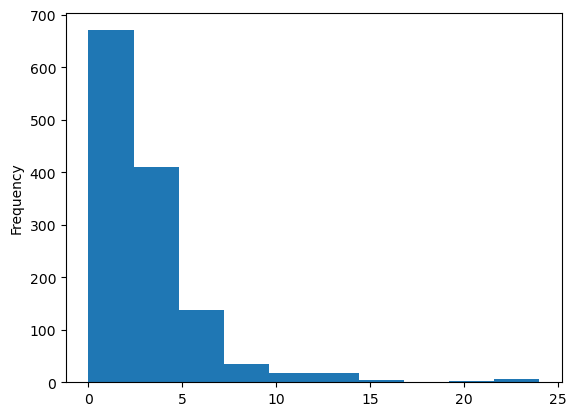

In [30]:
# histograms:

data.tvhours.plot(kind='hist')                                    # by default, 10 bins
plt.savefig('tv_hist10bins.jpg')                                  # save jpg to your local folder

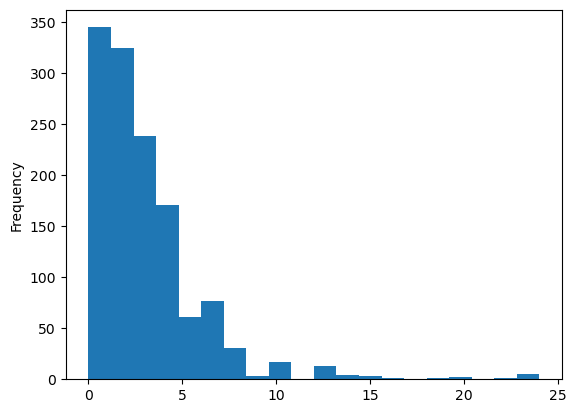

In [31]:
data.tvhours.plot(kind='hist', bins=20)                           # adjust # of bins
plt.savefig('tv_hist20bins.png')                                  # save jpg to your local folder

<p style="color:red">Always remember to add appropriate titles and x/y axis labels to your graphs. </p>

### For assignments/final project, graphs without proper titles and x/y axis labels will lead to reduced points. 

Text(0, 0.5, 'Number of Observations')

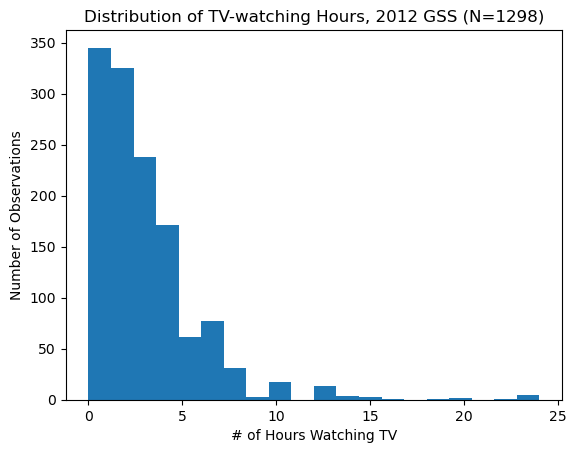

In [32]:
data.tvhours.plot(kind='hist', 
                  bins=20, 
                #  figsize=(8, 6),               # (width, height) in inches
                 )  

plt.title('Distribution of TV-watching Hours, 2012 GSS (N=1298)')
plt.xlabel('# of Hours Watching TV')
plt.ylabel('Number of Observations')

Another tool is called the **boxplot**. 

A boxplot divides the data into quartiles and visualizes them in a standardized manner as shown below:

<img src = 'https://clauswilke.com/dataviz/boxplots_violins_files/figure-html/boxplot-schematic-1.png' align = center width = 600>
<body><center>FDV Chp.9, Figure 9.2: Anatomy of a boxplot.</center></body>

Text(0, 0.5, '# of Hours Watching TV')

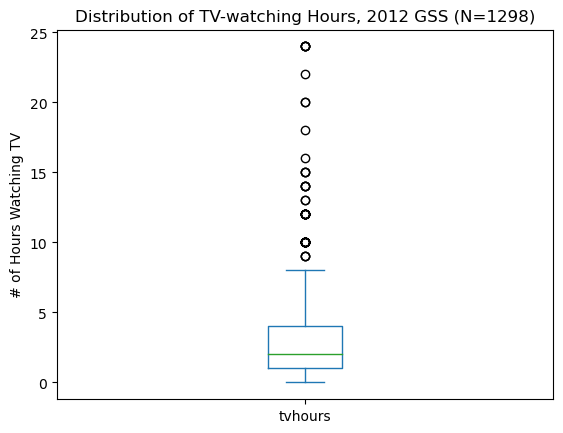

In [33]:
data.tvhours.plot(kind='box')                             # 25%, median, and 75%, then 1.5 times IQR

plt.title('Distribution of TV-watching Hours, 2012 GSS (N=1298)')
plt.ylabel('# of Hours Watching TV')

### Categorical variables:

Bar graphs (and its many variants) are commonly used for categorical variables. Pie charts can be used for visualizing simple proportions of a small numer (2-3) of categories, but we do not recommend pie charts for anything beyond this.  

**Bar graphs need to be sorted when there are more than 2 categories**, either descending/ascending or following the natural order of the variable (if ordinal).

#### For nominal variable: You must sort the variable ascendingly or descendingly first, then make the plot. 

In [42]:
data.groupby('race').size()

race
Black     301
Other     196
White    1477
dtype: int64

<AxesSubplot: xlabel='race'>

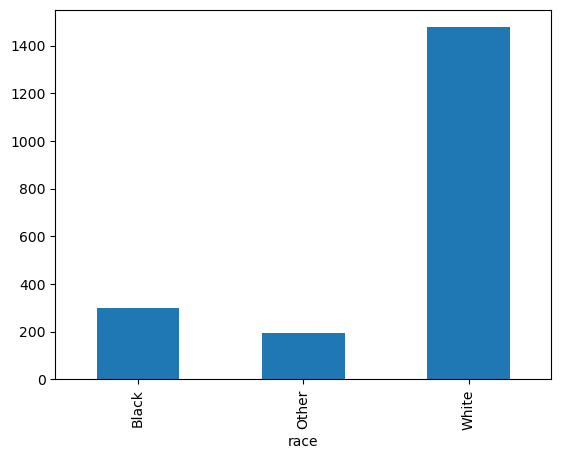

In [39]:
data.groupby('race').size().plot(kind='bar')     # WRONG GRAPH!! Did not sort!

In [40]:
# sort the values first!

data.groupby('race').size().sort_values()

race
Other     196
Black     301
White    1477
dtype: int64

Text(0, 0.5, 'Number of Observations')

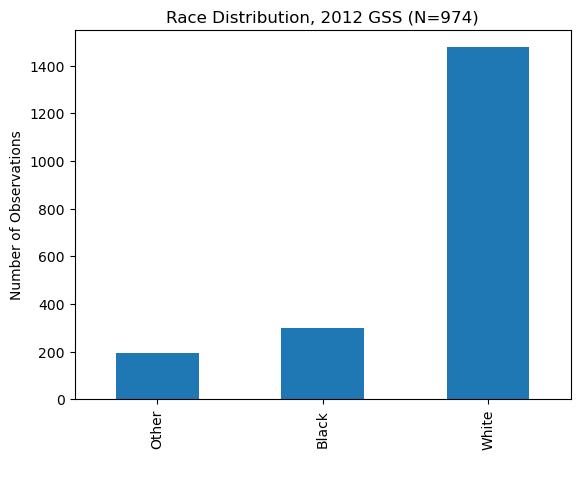

In [64]:
data.groupby('race').size().sort_values().plot(kind='bar')        # Correct graph

# always remember to add titles and labels once you finalze the graph!
plt.title('Race Distribution, 2012 GSS (N=974)')
plt.xlabel(' ')             # no label needed for obvious, self-explanatory categories
plt.ylabel('Number of Observations')

#### For ordinal variable: the bar graph must demonstrate its natural ordering. You should NOT sort ordinal variables ascendingly or descendingly!

<AxesSubplot: xlabel='pol'>

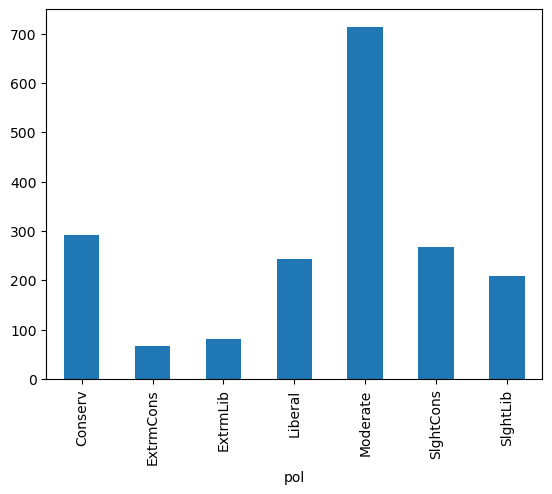

In [43]:
# no natural ordering

data.groupby('pol').size().plot(kind='bar')                  # WRONG GRAPH! No ordering

<AxesSubplot: xlabel='pol'>

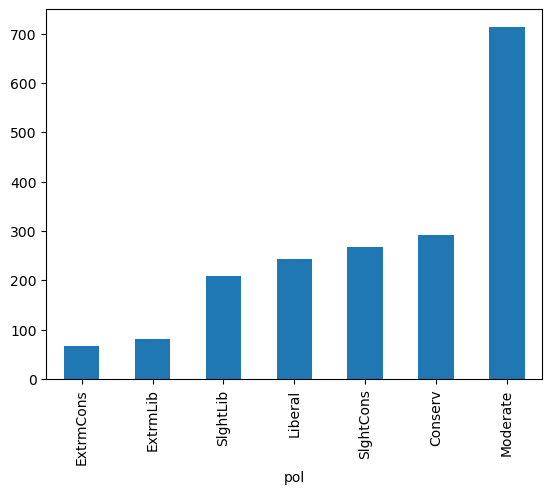

In [44]:
data.groupby('pol').size().sort_values().plot(kind='bar')     # WRONG GRAPH!  Cannot sort ordinal variables!

Text(0, 0.5, 'Number of Observations')

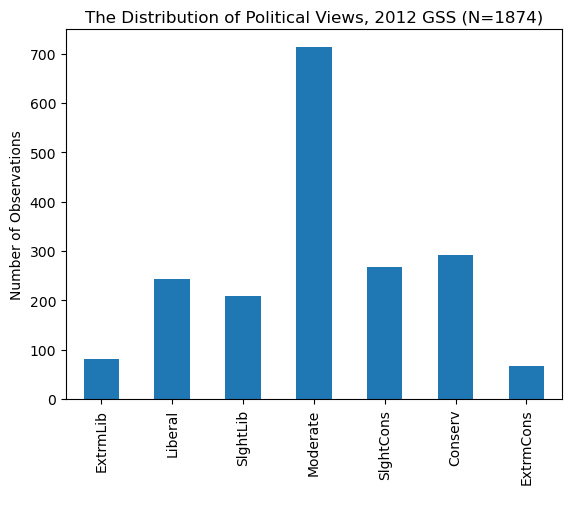

In [66]:
data.groupby('pol_ordered').size().plot(kind='bar')       # Correct graph

# always remember to add titles and labels once you finalze the graph!
plt.title('The Distribution of Political Views, 2012 GSS (N=1874)')
plt.xlabel(' ')             # no label needed for obvious, self-explanatory categories
plt.ylabel('Number of Observations')

#### When labels are long or hard to read, or when there are many categories, it is recommened to use horizontal bar graphs instead:

Text(0, 0.5, ' ')

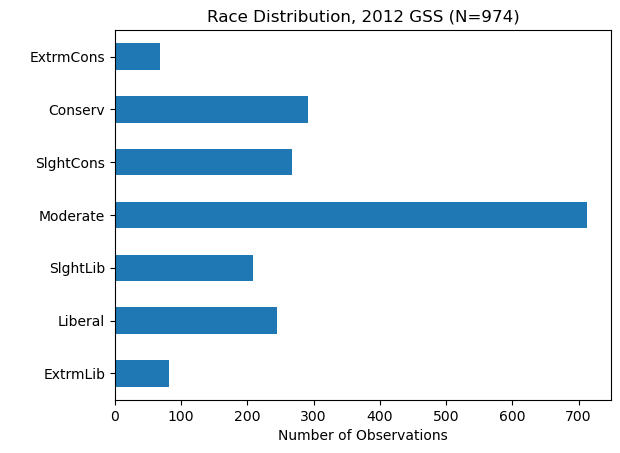

In [67]:
data.groupby('pol_ordered').size().plot(kind='barh')        # add title and axis labels   

# always remember to add titles and labels once you finalze the graph!
plt.title('Race Distribution, 2012 GSS (N=974)')
plt.xlabel('Number of Observations')
plt.ylabel(' ')             # no label needed for obvious, self-explanatory categories


## Bivariate Analysis <a id=2.2></a>

When it comes to the relationship between two variables, there are three possible scenarios:

1. categorical v.s. categorical
2. categorical v.s. numerical
3. numerical v.s. numerical

Regardless, both the `groupby()`/`pivot_table()` functions and the `.plot()` method would help you explore the relationships. 

### Categorical v.s. Categorical
Let's talk about the first scenario first, using `pres` and `pol_order` as an example:

#### A note on `pivot_table`

When your `groupby()` method involves multiple dimensions, the output may be confusing and hard to read. 

In [70]:
# use groupby to get bivariate distribution:

data.groupby(['pol_ordered', 'pres']).size()

pol_ordered  pres  
ExtrmLib     McCain      6
             Obama      49
Liberal      McCain      8
             Obama     162
SlghtLib     McCain     14
             Obama     132
Moderate     McCain    100
             Obama     276
SlghtCons    McCain     97
             Obama      85
Conserv      McCain    177
             Obama      35
ExtrmCons    McCain     37
             Obama       9
dtype: int64

But when you use pivot table, it is organized in a clear and compact way! 

In [49]:
# pivot table provides a better view and is better for visualization

data.pivot_table(columns='pol_ordered', 
                 index='pres', 
                 
                 values='id',                   # obtain headcount
                 aggfunc='count',
                 fill_value = 0
                 )  

# returns a dataframe, can be saved for future use!

pol_ordered,ExtrmLib,Liberal,SlghtLib,Moderate,SlghtCons,Conserv,ExtrmCons
pres,,,,,,,
McCain,6,8,14,100,97,177,37
Obama,49,162,132,276,85,35,9


The above table can be called a "contingency table" (please refer to your stats classes for a review). Essentially, it is a DataFrame, and can be saved to a variable for future use. 

Therefore, after you create the contingency table with `groupby` or `pivot_table`, you can save it to a variable and pass it to certain functions from other packages for other statistical analysis, e.g. `scipy` for [chi-square tests](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).

We will talk more about this in the next session.

Now let's come back to the exploration of our dataset:

We often use **grouped bar graphs** to visualize the distribution over two categorical variables. 

<AxesSubplot: xlabel='pres'>

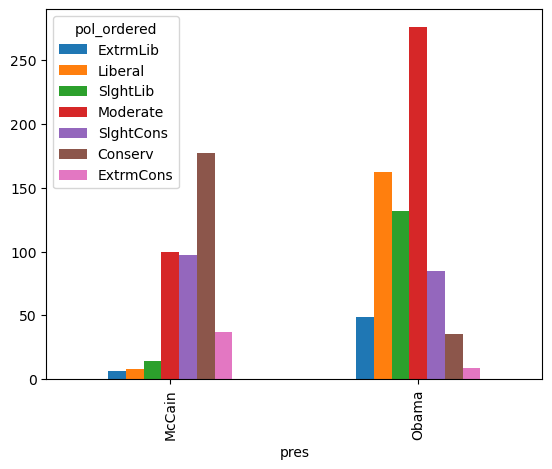

In [51]:
data.pivot_table(index="pres",
                 columns="pol_ordered",
                 values="id",
                 aggfunc='count').plot(kind='bar')

# Wrong graph. Ugly and not effective

The plot is quite...ugly, and ineffective in some sense (the color choices are really bad). **If this plot is not for your personal use, you need to make it aesthetically pleasing and effective for communication** -- these are more advanced topics of data visualization.  

### Another important aspect of data visualization is **the layout** of your plots. 

You can draw very different plots based on exactly the same data. And **they are different not only in terms of the art, but also in terms of the specific messages that they deliver.** This influences what kind of stories you can tell!

For instance, the above grouped bar can be converted to a stacked bar graph. Can you compare the two plots and tell what different messages they deliver?

<AxesSubplot: xlabel='pol_ordered'>

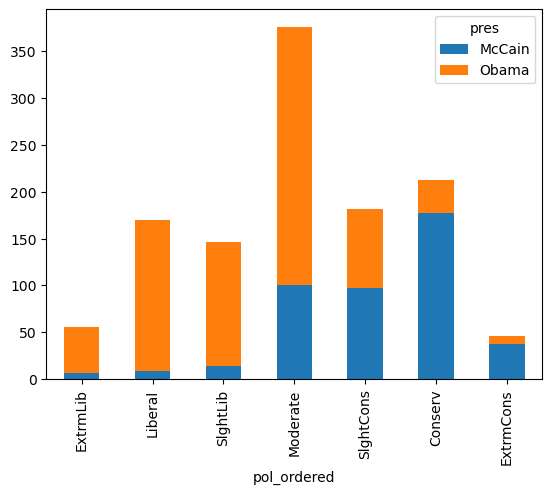

In [74]:
data.pivot_table(index="pol_ordered",
                 columns="pres",                                         # swap index and columns!
                 values="id",              
                 aggfunc='count').plot(kind='bar',   
                                       #figsize=(8, 6),                  # adjust figure size
                                       stacked=True)

# WRONG graph. Unbalanced categories, hard to compare and could be misleading

Because of the unbalanced data distribution over political view categories (some categories have over 350 people while some have less than 50), the plot does not show clear & comparable patterns of voting decisions in different ideological groups. To solve this problem, we can further tweak the plot and show percentages instead of counts. 

A easy way to do this is to use a function, `pd.crosstab`, whose syntax is very similiar to that of `df.pivot_table`.

In [55]:
pd.crosstab(index=data.pol_ordered, 
            columns=data.pres, 
            values=data.id, 
            aggfunc='count', 
            
            normalize='index'           # convert count to percentages, check docstring for other methods of normalization
           )                      

# returns a dataframe, can be saved for future use!

pres,McCain,Obama
pol_ordered,,
ExtrmLib,0.109091,0.890909
Liberal,0.047059,0.952941
SlghtLib,0.095890,0.904110
Moderate,0.265957,0.734043
SlghtCons,0.532967,0.467033
Conserv,0.834906,0.165094
ExtrmCons,0.804348,0.195652


<AxesSubplot: xlabel='pol_ordered'>

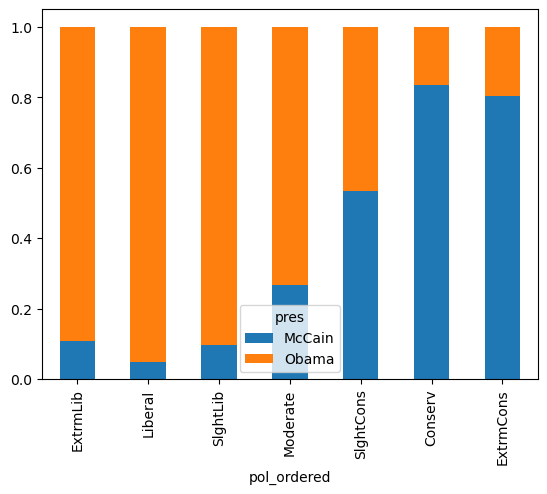

In [68]:
pd.crosstab(values=data.id, 
            index=data.pol_ordered, 
            columns=data.pres,                       
            aggfunc='count', 
            normalize='index').plot(kind='bar', 
                                    stacked=True)      # correct graph

Text(0, 0.5, 'political views')

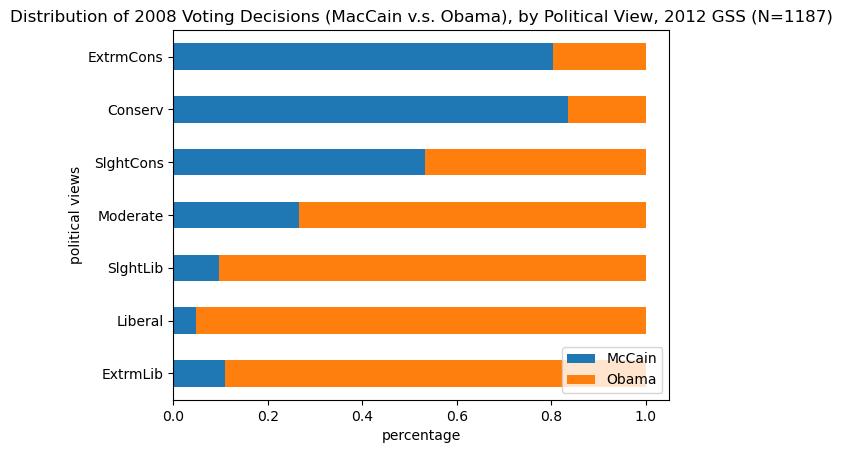

In [73]:
# edit the graph to make it effective and aesthetically pleasing.

fig = pd.crosstab(values=data.id, 
            index=data.pol_ordered, 
            columns=data.pres,                       
            aggfunc='count', 
            normalize='index').plot(kind='barh', 
                                    stacked=True)
# change the location of legend
fig.legend(loc='lower right')


# always remember to add titles and labels once you finalze the graph!
plt.title('Distribution of 2008 Voting Decisions (MacCain v.s. Obama), by Political View, 2012 GSS (N=1187)')
plt.xlabel('percentage')       
plt.ylabel('political views')
    

Check out more examples and code on [bar plots with pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.bar.html).

# More Resources <a id=3></a>

## A Note on Aesthetics and Styles

Before you make plots, you can choose a specific style for visualization.

In [77]:
plt.style.available                             # check documentation to see each style

['Solarize_Light2',
 '_classic_test_patch',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'seaborn',
 'seaborn-bright',
 'seaborn-colorblind',
 'seaborn-dark',
 'seaborn-dark-palette',
 'seaborn-darkgrid',
 'seaborn-deep',
 'seaborn-muted',
 'seaborn-notebook',
 'seaborn-paper',
 'seaborn-pastel',
 'seaborn-poster',
 'seaborn-talk',
 'seaborn-ticks',
 'seaborn-white',
 'seaborn-whitegrid',
 'tableau-colorblind10']

In [78]:
plt.style.use('ggplot')

Now if you re-run the code for plotting, you will see graphs with different aethetics!

## General Principles about Data Visualization:
[Fundamentals of Data Visualization](https://clauswilke.com/dataviz/) by Claus O. Wilke.

## Programming Tutorials for Data Visualization:
[Plot with Pandas: Python Data Visualization for Beginners (RealPython)](https://realpython.com/pandas-plot-python/)

[Python Plotting with Matplotlib (RealPython)](https://realpython.com/python-matplotlib-guide/)

[DataCamp: Introduction to Data Visualization in Python](https://learn.datacamp.com/courses/introduction-to-data-visualization-in-python)

[DataCamp: Introduction to Data Visualization with Seaborn](https://learn.datacamp.com/courses/introduction-to-data-visualization-with-seaborn)

---
Copyright &copy; 2024 Yinxian Zhang | Department of Sociology | City University of New York, Queens College